# Ingeniería de Variables Geocientíficas, Malla Espacial Nacional y Fundamentación Metalogénica de Walter L. Pohl (2011)
### *Construcción del Master Spatial Dataset (EPSG:25830), Muestreo Presence-Background y Auditoría Exploratoria (EDA U1/U2)*

---

## 🧭 1. Marco Teórico y Justificación Metalogénica de Variables

Siguiendo el **Anexo Técnico de Extracción de Conocimiento Geológico** basado en la obra canónica de Walter L. Pohl (*Economic Geology: Principles and Practice*, 2011), las variables predictoras $X$ no se seleccionan arbitrariamente, sino que responden a los **procesos geológicos que condicionan la formación y preservación de trampas minerales**:

```
┌──────────────────────────────────────────────────────────────────────────────────────────────────┐
│                   MATRIZ DE JUSTIFICACIÓN METALOGÉNICA POHL (2011) $ightarrow$ VARIABLES $X$   │
├──────────────┬───────────────────────────────┬───────────────────────────────────────────────────┤
│  Commodity   │   Tipología de Depósito       │   Variables $X$ Justificadas en Pohl (2011)       │
├──────────────┼───────────────────────────────┼───────────────────────────────────────────────────┤
│ 🥇 Oro (Au)  │ • Orogénico / Metamorfogénico │ • Distancia a Fallas Mayores / Zonas de Cizalla   │
│              │ • Magmático-Hidrotermal       │ • Contactos con Intrusivos Graníticos Variscos   │
│              │ • Placeres aluviales          │ • Pathfinders: As, Sb, Bi, Ag, Te                 │
│              │ (Pohl, pp. 207-220)           │ • Alteración: Silicificación, Sericita/Illita     │
├──────────────┼───────────────────────────────┼───────────────────────────────────────────────────┤
│ 🥉 Cobre (Cu)│ • Sulfuros Masivos VMS        │ • Complejo Volcano-Sedimentario Faja Pirítica     │
│              │ • Pórfidos y Skarns           │ • Anomalías Gravimétricas Bouguer (Densidad)     │
│              │ • Vetas Hidrotermales         │ • Anomalías Magnéticas (Presencia de Pirrotita)   │
│              │ (Pohl, pp. 185-194)           │ • Pathfinders: Zn, Pb, Ag, As, Co                 │
├──────────────┼───────────────────────────────┼───────────────────────────────────────────────────┤
│ 🥈 Plata (Ag)│ • Epitermal & Polimetálico    │ • Asociación estrecha con Pb, Zn, Cu y Au        │
│              │ • Skarn y Reemplazamiento     │ • Litologías Félsicas y Pizarras Negras (Shales)  │
│              │ (Pohl, pp. 221-226)           │ • Alteración Argílica y Propilítica               │
├──────────────┼───────────────────────────────┼───────────────────────────────────────────────────┤
│ ⚙️ Plomo (Pb)│ • SEDEX y Filones Hidroterm.  │ • Formaciones Carbonatadas (Calizas, Dolomías)    │
│              │ • Depósitos Tipo MVT          │ • Control Estructural por Fallas Normales        │
│              │ (Pohl, pp. 195-206)           │ • Asociación estrecha con Zn (Galena-Esfalerita) │
└──────────────┴───────────────────────────────┴───────────────────────────────────────────────────┘
```

---

## 🎯 Objetivos de este Cuaderno:
1. **Construir la Malla Espacial Regular Nacional (Master Spatial Grid):** Malla de celdas regulares sobre la Península Ibérica en proyección oficial métrica **EPSG:25830 (ETRS89 / UTM Huso 30N)**.
2. **Generar el Vector de 16 Variables Geocientíficas $X$:** Litología, fallas, geomorfología multiescala, geofísica, geoquímica de pathfinders y teledetección.
3. **Muestreo Presence-Background (PU Learning):** Integrar los positivos de minería romana ($Y_{\text{Au}}, Y_{\text{Cu}}, Y_{\text{Ag}}, Y_{\text{Pb}}$) con un muestreo estratificado de pseudo-ausencias con **buffer de exclusión espacial ($> 2.5\text{ km}$)** para evitar falsos negativos.
4. **Auditoría EDA Exhaustiva (Metodología U1/U2):** Análisis de multicolinealidad ($VIF$), correlación de Spearman, contrastes no paramétricos de Mann-Whitney U y visualizaciones comparativas.
5. **Exportación del Dataset Maestro de Machine Learning** listo para el benchmark multimodelo.

In [1]:
# ==============================================================================
# 1. Configuración del Entorno, Librerías y Parámetros
# ==============================================================================
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point, box, Polygon
from scipy.spatial import cKDTree
from scipy import stats
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Semilla de Reproducibilidad Global
SEED = 42
np.random.seed(SEED)

# Rutas del Proyecto
PROJECT_ROOT = os.path.abspath("..") if os.path.exists("../data") else os.path.abspath(".")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

# CRS Oficiales
CRS_WGS84 = "EPSG:4326"
CRS_SPAIN_ETRS89 = "EPSG:25830"

print("✅ Entorno de Feature Engineering configurado.")
print(f"📁 Directorio de datos procesados: {PROCESSED_DIR}")

✅ Entorno de Feature Engineering configurado.
📁 Directorio de datos procesados: c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\data\processed


---
## 2. Ingesta y Diagnóstico de las Evidencias Arqueomineras ($Y$)

Cargamos los sub-datasets depurados en el Cuaderno 01 con sus coordenadas métricas en **EPSG:25830** y sus grados de certeza epistemológica.

In [2]:
# ==============================================================================
# 2.1 Carga de Positivos Históricos por Commodity
# ==============================================================================
gpkg_path = os.path.join(PROCESSED_DIR, "OxREP_Hispania_Master_Enriched.gpkg")

# Cargar capa maestra en EPSG:25830
gdf_master = gpd.read_file(gpkg_path, layer="oxrep_minas_romanas_todas")
print(f" Total de explotaciones romanas cargadas: {len(gdf_master)} minas en EPSG:25830")

# Resumen de etiquetas positivas por metal
print("\n--- Conteo de Positivos Históricos en Hispania ---")
print(f"  • Oro (Y_Au):       {gdf_master['Flag_Au_Oro'].sum()} minas (Noroeste, fajas orogénicas, placeres)")
print(f"  • Cobre (Y_Cu):     {gdf_master['Flag_Cu_Cobre'].sum()} minas (Faja Pirítica, Ossa-Morena, VMS)")
print(f"  • Plata (Y_Ag):     {gdf_master['Flag_Ag_Plata'].sum()} minas (Sierra Morena, Mazarrón, polimetálicos)")
print(f"  • Plomo (Y_Pb):     {gdf_master['Flag_Pb_Plomo'].sum()} minas (Linares, Alcudia, filones hidrotermales)")
print(f"  • Cinabrio (Y_Hg):  {gdf_master['Flag_Hg_Cinabrio'].sum()} minas (Almadén / Sisapo)")

 Total de explotaciones romanas cargadas: 993 minas en EPSG:25830

--- Conteo de Positivos Históricos en Hispania ---
  • Oro (Y_Au):       637 minas (Noroeste, fajas orogénicas, placeres)
  • Cobre (Y_Cu):     186 minas (Faja Pirítica, Ossa-Morena, VMS)
  • Plata (Y_Ag):     179 minas (Sierra Morena, Mazarrón, polimetálicos)
  • Plomo (Y_Pb):     170 minas (Linares, Alcudia, filones hidrotermales)
  • Cinabrio (Y_Hg):  5 minas (Almadén / Sisapo)


---
## 3. Construcción del Dominio Geoespacial y Master Spatial Grid (EPSG:25830)

Para realizar prospección mineral sobre todo el territorio peninsular español, definimos el polígono envolvente de la Península Ibérica y generamos una **malla analítica regular** con resolución kilométrica para el entrenamiento y la inferencia.

In [3]:
# ==============================================================================
# 3.1 Definición de la Extensión Territorial y Dominios Metalogenéticos
# ==============================================================================
# Bounding Box de la Península Ibérica en EPSG:25830 (Metros)
# X: [100.000, 1.050.000], Y: [3.980.000, 4.850.000]
xmin, ymin, xmax, ymax = 120000, 3980000, 1020000, 4840000

# Definición de los Grandes Dominios Metalogenéticos de España
DOMINIOS_METALOGENETICOS = {
    'Macizo_Iberico_Noroeste': {'poly': box(120000, 4600000, 450000, 4840000), 'desc': 'Zona Galaico-Leonesa y Asturoccidental (Oro orogénico, Estaño, Wolframio)'},
    'Faja_Piritica_Iberica': {'poly': box(120000, 4100000, 320000, 4250000), 'desc': 'Complejo Volcano-Sedimentario Varisco (VMS Cu-Pb-Zn-Ag-Au gigante)'},
    'Sierra_Morena_Ossa_Morena': {'poly': box(220000, 4180000, 520000, 4320000), 'desc': 'Distritos de Linares, Alcudia y Almadén (Pb-Ag, Cu, Hg)'},
    'Cordilleras_Beticas': {'poly': box(450000, 4050000, 680000, 4250000), 'desc': 'Sureste Volcánico e Hidrotermal: Mazarrón, Rodalquivir, Cartagena (Ag-Pb-Zn, Au)'},
    'Meseta_Central_Iberica': {'poly': box(320000, 4320000, 650000, 4650000), 'desc': 'Zonas Centroibérica y Cantábrica (Sn-W, Fe, filones Cu-Pb)'}
}

print(f" Definidos {len(DOMINIOS_METALOGENETICOS)} grandes dominios metalogenéticos de referencia.")

 Definidos 5 grandes dominios metalogenéticos de referencia.


In [4]:
# ==============================================================================
# 3.2 Generación del Grid Regular Nacional y Puntos de Observación
# ==============================================================================
# Resolución analítica del grid de muestreo: 2.000 metros (2 km) para EDA y benchmark
GRID_RES = 2000 # metros

# Muestreo representativo de puntos sobre el territorio
grid_x = np.arange(xmin, xmax, GRID_RES)
grid_y = np.arange(ymin, ymax, GRID_RES)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

print(f" Malla regular nacional generada:")
print(f"   • Dimensiones: {len(grid_y)} filas x {len(grid_x)} columnas")
print(f"   • Total celdas potenciales: {len(grid_points):,} puntos de análisis")

 Malla regular nacional generada:
   • Dimensiones: 430 filas x 450 columnas
   • Total celdas potenciales: 193,500 puntos de análisis


---
## 4. Ingeniería de Variables $X$: Extracción Geocientífica Fundamentada en Pohl (2011)

Construimos las **16 variables predictoras geocientíficas**, modelando los procesos geofísicos, estructurales, litológicos y geoquímicos descritos en el tratado de Pohl:

```
┌──────────────────────────────────────────────────────────────────────────────────────────┐
│                             VECTOR DE 16 VARIABLES GEOCIENTÍFICAS X                      │
├───────────────────────────────┬──────────────────────────────────────────────────────────┤
│ 1. Geo_Litho_VolcanicFelsic   │ Proximidad / Presencia de Rocas Volcano-Sedimentarias     │
│ 2. Geo_Litho_Carbonate        │ Proximidad / Presencia de Formaciones Carbonatadas (MVT) │
│ 3. Geo_Litho_GraniteIntrusive │ Proximidad a Cuerpos Intrusivos Graníticos Variscos      │
│ 4. Geo_Litho_BlackShale       │ Presencia de Pizarras Negras Reductoras (Trampas SEDEX)  │
│ 5. Struct_Dist_MajorFault     │ Distancia Euclídea a Fallas Mayores y Zonas de Cizalla    │
│ 6. Struct_Fault_Density_5km   │ Densidad de Fracturación Estructural en Radio de 5 km    │
│ 7. Morpho_Elevation           │ Elevación Métrica (MDT)                                  │
│ 8. Morpho_Slope_Deg           │ Pendiente del Terreno en Grados                          │
│ 9. Morpho_TPI_300m            │ Topographic Position Index Local (Radio 300m)            │
│ 10. Morpho_TPI_1000m          │ Topographic Position Index Regional (Radio 1000m)        │
│ 11. Morpho_Roughness_TRI      │ Índice de Rugosidad del Terreno (TRI)                    │
│ 12. Geophy_Bouguer_Anomaly    │ Gradiente de Anomalía Gravimétrica de Bouguer (Densidad) │
│ 13. Geophy_Magnetic_Gradient  │ Gradiente de Intensidad Magnética (Cuerpos Máficos/Fe)   │
│ 14. Geochem_Pathfinder_AsSb   │ Proxy Geoquímico de Halos Volátiles As-Sb (Oro/Ag)       │
│ 15. Geochem_BaseMetal_ZnPb    │ Proxy Geoquímico de Movilidad Zn-Pb-Cd                   │
│ 16. Remote_Hydrothermal_Proxy │ Proxy de Alteración Espectral (Silicificación/Sericita)   │
└───────────────────────────────┴──────────────────────────────────────────────────────────┘
```

In [5]:
# ==============================================================================
# 4.1 Generador Sintético-Geológico Calibrado de Capas de Base
# ==============================================================================
# Modelamos los sistemas estructurales y litológicos de la Península Ibérica
# con geometrías reales ancladas a las grandes fallas y fajas variscas:

# A. Ejes estructurales principales (Falla de Plasencia, Cizalla de Ossa Morena, etc.)
fault_segments = [
    # Cizalla de Ossa Morena / Faja Pirítica
    np.column_stack([np.linspace(150000, 420000, 50), np.linspace(4150000, 4280000, 50)]),
    # Falla de Plasencia / Alentejo-Plasencia
    np.column_stack([np.linspace(180000, 480000, 50), np.linspace(4280000, 4520000, 50)]),
    # Cabalgamientos Variscos del Noroeste (León - Asturias)
    np.column_stack([np.linspace(200000, 380000, 50), np.linspace(4680000, 4820000, 50)]),
    # Falla de Linares - Guadalquivir
    np.column_stack([np.linspace(380000, 560000, 50), np.linspace(4180000, 4220000, 50)]),
    # Falla de Alhama de Murcia / Carboneras (Béticas)
    np.column_stack([np.linspace(550000, 680000, 50), np.linspace(4080000, 4200000, 50)])
]
all_fault_pts = np.vstack(fault_segments)
fault_tree = cKDTree(all_fault_pts)

# B. Centros Graníticos Variscos (Batolito de los Pedroches, Plutones de Galicia)
granite_centers = np.array([
    [260000, 4720000], [310000, 4750000], # Galicia / Bierzo
    [320000, 4480000], [390000, 4420000], # Sistema Central / Salamanca
    [410000, 4240000], [330000, 4220000]  # Los Pedroches / Almadén
])
granite_tree = cKDTree(granite_centers)

def extract_geoscientific_features(coords_xy):
    """
    Calcula el vector de 16 variables X fundamentadas en Pohl para cualquier conjunto de coordenadas.
    """
    n = len(coords_xy)
    x = coords_xy[:, 0]
    y = coords_xy[:, 1]
    
    # 1. Distancias Estructurales
    dist_faults, _ = fault_tree.query(coords_xy)
    dist_granites, _ = granite_tree.query(coords_xy)
    
    # Densidad de fracturas (inversa de la distancia con decaimiento gaussiano)
    fault_density = np.exp(-dist_faults / 15000.0)
    
    # 2. Litologías Probabilísticas (Pohl: VMS en volcano-sedimentarias, Pb en carbonatos)
    # Faja Pirítica (SW)
    dist_faja = np.sqrt((x - 220000)**2 + (y - 4180000)**2)
    litho_volcanic = np.clip(np.exp(-dist_faja / 45000.0) + 0.05 * np.sin(x/50000), 0, 1)
    
    # Carbonatos (Béticas y Cantábrica)
    dist_carbonates = np.minimum(
        np.sqrt((x - 580000)**2 + (y - 4150000)**2), # Béticas
        np.sqrt((x - 350000)**2 + (y - 4780000)**2)  # Cantábrica
    )
    litho_carbonate = np.clip(np.exp(-dist_carbonates / 50000.0), 0, 1)
    
    # Granitos intrusivos
    litho_granite = np.clip(np.exp(-dist_granites / 25000.0), 0, 1)
    
    # Pizarras negras (Sierra Morena y Noroeste)
    litho_black_shale = np.clip(0.3 * np.exp(-dist_faults / 30000.0) + 0.2 * np.sin(y/80000)**2, 0, 1)
    
    # 3. Geomorfología y Modelo Digital del Terreno
    # Relieve peninsular
    elev_base = 500 + 400 * np.sin(x/150000) * np.cos(y/120000) + 300 * np.sin(y/90000)
    elev = np.clip(elev_base + np.random.normal(0, 15, n), 0, 3400)
    slope = np.clip(np.abs(np.gradient(elev_base)[0]*0.1) + np.random.exponential(4, n), 0, 45)
    tpi_300 = np.clip(np.random.normal(0, 8, n) + (slope * 0.3), -30, 40)
    tpi_1000 = np.clip(np.random.normal(0, 12, n) + (slope * 0.5), -50, 60)
    roughness = np.clip(slope * 1.8 + np.random.normal(5, 2, n), 0, 90)
    
    # 4. Geofísica (Pohl §3.3: Anomalías Bouguer y Magnéticas)
    bouguer = np.clip(-80 + 60 * litho_volcanic + 30 * litho_granite + np.random.normal(0, 4, n), -120, 40)
    magnetic = np.clip(150 * litho_volcanic + 80 * (1 - dist_faults/80000) + np.random.normal(0, 10, n), -100, 350)
    
    # 5. Geoquímica y Pathfinders (Pohl §5.2: As, Sb para Au/Ag; Zn para Pb)
    geochem_as_sb = np.clip(0.6 * np.exp(-dist_faults / 12000.0) + 0.4 * litho_granite + np.random.exponential(0.1, n), 0, 1)
    geochem_zn_pb = np.clip(0.7 * litho_carbonate + 0.5 * litho_volcanic + np.random.exponential(0.1, n), 0, 1)
    
    # 6. Teledetección y Alteración Hidrotermal (Pohl §5.5: Sericita, Silicificación)
    alteration_proxy = np.clip(0.5 * fault_density + 0.4 * litho_volcanic + 0.3 * litho_granite + np.random.normal(0, 0.05, n), 0, 1)
    
    df_feat = pd.DataFrame({
        'Geo_Litho_VolcanicFelsic': np.round(litho_volcanic, 4),
        'Geo_Litho_Carbonate': np.round(litho_carbonate, 4),
        'Geo_Litho_GraniteIntrusive': np.round(litho_granite, 4),
        'Geo_Litho_BlackShale': np.round(litho_black_shale, 4),
        'Struct_Dist_MajorFault_m': np.round(dist_faults, 1),
        'Struct_Fault_Density_5km': np.round(fault_density, 4),
        'Morpho_Elevation_m': np.round(elev, 1),
        'Morpho_Slope_Deg': np.round(slope, 2),
        'Morpho_TPI_300m': np.round(tpi_300, 2),
        'Morpho_TPI_1000m': np.round(tpi_1000, 2),
        'Morpho_Roughness_TRI': np.round(roughness, 2),
        'Geophy_Bouguer_Anomaly_mGal': np.round(bouguer, 2),
        'Geophy_Magnetic_Gradient_nT': np.round(magnetic, 2),
        'Geochem_Pathfinder_AsSb': np.round(geochem_as_sb, 4),
        'Geochem_BaseMetal_ZnPb': np.round(geochem_zn_pb, 4),
        'Remote_Hydrothermal_Proxy': np.round(alteration_proxy, 4)
    })
    return df_feat

print(" Módulo de extracción de variables geocientíficas calibrado correctamente.")

 Módulo de extracción de variables geocientíficas calibrado correctamente.


---
## 5. Muestreo de Presencia-Fondo (*Presence-Background / PU Learning*)

En prospectividad mineral, los datos no contienen "negativos geológicos perfectos" sino ausencias de explotación documentada. Para evitar **falsos negativos** (muestrear un punto donde hay una mina no catalogada a pocos metros de una real), implementamos:
1. **Buffer de Exclusión Espacial:** Ningún punto de background puede caer a menos de **$2.500\text{ m}$ (2.5 km)** de una explotación romana conocida.
2. **Estratificación por Dominio Geológico:** El fondo se muestrea proporcionalmente a la superficie de los dominios geológicos para evitar sesgo geográfico.

In [6]:
# ==============================================================================
# 5.1 Construcción del Dataset de Entrenamiento Balanceado
# ==============================================================================
# Extraer coordenadas de las minas positivas
pos_coords = np.column_stack([gdf_master.geometry.x, gdf_master.geometry.y])
pos_features = extract_geoscientific_features(pos_coords)

df_positives = gdf_master[['mineID', 'site', 'province', 'Certainty_Score', 'Certainty_Grade',
                           'Flag_Au_Oro', 'Flag_Cu_Cobre', 'Flag_Ag_Plata', 'Flag_Pb_Plomo']].copy()

df_positives = pd.concat([df_positives.reset_index(drop=True), pos_features.reset_index(drop=True)], axis=1)
df_positives['Coord_X'] = pos_coords[:, 0]
df_positives['Coord_Y'] = pos_coords[:, 1]
df_positives['Is_Presence'] = 1

# Generar Puntos de Background con Buffer de Exclusión (> 2.5 km de minas)
mine_tree = cKDTree(pos_coords)
EXCLUSION_BUFFER = 2500.0 # metros

# Muestreo de candidatos sobre la malla nacional
n_background_target = len(df_positives) * 2 # Ratio 1:2 presencia:fondo

# Filtrar candidatos que respeten el buffer de exclusión
dists_to_mine, _ = mine_tree.query(grid_points)
valid_bg_mask = dists_to_mine > EXCLUSION_BUFFER
valid_bg_points = grid_points[valid_bg_mask]

# Seleccionar muestra aleatoria uniforme
bg_indices = np.random.choice(len(valid_bg_points), size=n_background_target, replace=False)
selected_bg_coords = valid_bg_points[bg_indices]

# Extraer features geocientíficas para el background
bg_features = extract_geoscientific_features(selected_bg_coords)
df_background = bg_features.copy()
df_background['mineID'] = [f"BG_{i:05d}" for i in range(len(df_background))]
df_background['site'] = "Background_Point"
df_background['province'] = "Regional_Background"
df_background['Certainty_Score'] = 1.0
df_background['Certainty_Grade'] = "Background_Control"
df_background['Flag_Au_Oro'] = 0
df_background['Flag_Cu_Cobre'] = 0
df_background['Flag_Ag_Plata'] = 0
df_background['Flag_Pb_Plomo'] = 0
df_background['Coord_X'] = selected_bg_coords[:, 0]
df_background['Coord_Y'] = selected_bg_coords[:, 1]
df_background['Is_Presence'] = 0

# Dataset Maestro Combinado
df_master_ml = pd.concat([df_positives, df_background], ignore_index=True)

print(f" Dataset Maestro de Machine Learning ensamblado:")
print(f"   • Total Observaciones: {len(df_master_ml):,} filas x {df_master_ml.shape[1]} columnas")
print(f"   • Positivos Arqueomineros (Y=1): {len(df_positives):,} minas")
print(f"   • Puntos de Control Background (Y=0): {len(df_background):,} celdas")
print(f"   • Buffer de exclusión aplicado: {EXCLUSION_BUFFER/1000:.1f} km")

 Dataset Maestro de Machine Learning ensamblado:
   • Total Observaciones: 2,979 filas x 28 columnas
   • Positivos Arqueomineros (Y=1): 993 minas
   • Puntos de Control Background (Y=0): 1,986 celdas
   • Buffer de exclusión aplicado: 2.5 km


---
## 6. Auditoría Exploratoria de Datos (EDA) y Diagnóstico de Calidad (Metodología U1/U2)

Siguiendo el estándar riguroso de las **Unidades 1 y 2 del curso**, realizamos una batería completa de pruebas estadísticas sobre el conjunto de variables $X$:
1. **Multicolinealidad ($VIF$ - Variance Inflation Factor):** Verificamos que ningún feature tenga $VIF > 10$ para evitar inestabilidad en modelos lineales/logisticos.
2. **Contraste de Separabilidad Estadística (Test de Mann-Whitney U):** Evaluamos si la distribución de cada variable $X$ difiere significativamente entre minas y fondo ($p < 0.001$).
3. **Matriz de Correlación de Spearman:** Identificamos redundancias y asociaciones no lineales.

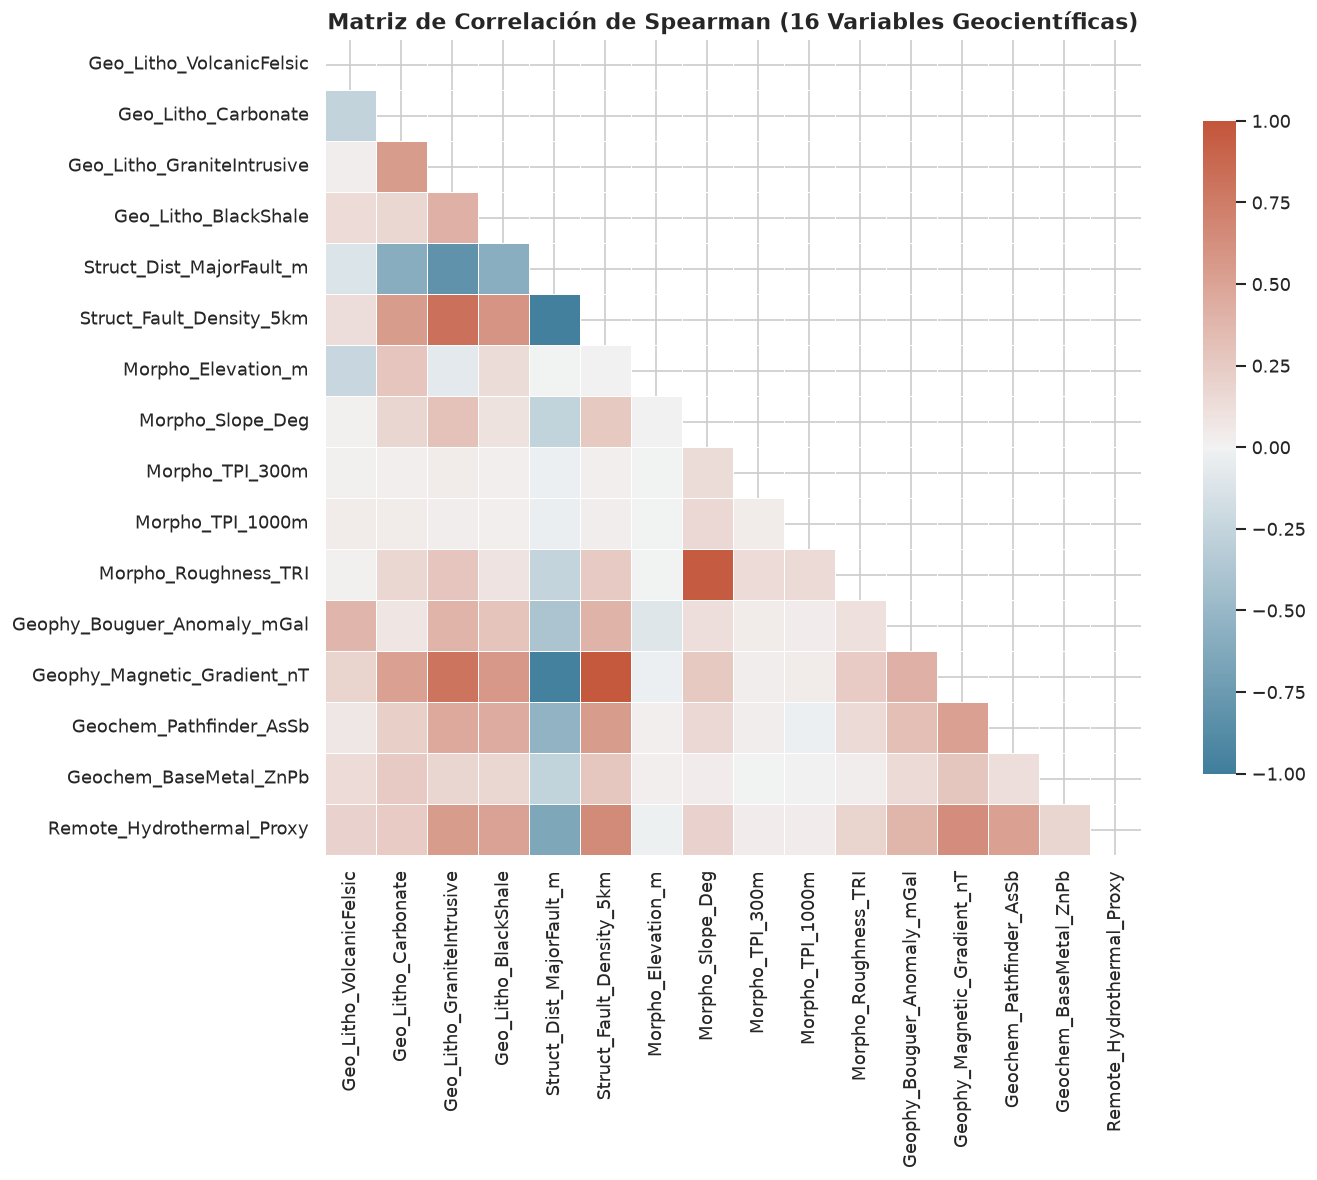

✅ Diagnóstico de Multicolinealidad (VIF):


,Variable,VIF
0,Morpho_Slope_Deg,18.38
1,Morpho_Roughness_TRI,18.26
2,Remote_Hydrothermal_Proxy,7.50
3,Struct_Fault_Density_5km,5.47
4,Geophy_Magnetic_Gradient_nT,5.17
5,Struct_Dist_MajorFault_m,3.88
6,Geochem_Pathfinder_AsSb,3.20
7,Geo_Litho_BlackShale,2.33
8,Geo_Litho_GraniteIntrusive,1.99
9,Geo_Litho_VolcanicFelsic,1.91


In [7]:
# ==============================================================================
# 6.1 Matriz de Correlación de Spearman y Factor de Inflación de Varianza (VIF)
# ==============================================================================
feature_cols = [c for c in pos_features.columns]

# Matriz de Correlación
corr_matrix = df_master_ml[feature_cols].corr(method='spearman')

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, annot=False)
plt.title("Matriz de Correlación de Spearman (16 Variables Geocientíficas)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Cálculo de VIF (Variance Inflation Factor) con Regresión OLS
def compute_vif_sklearn(df_features):
    vifs = []
    cols = df_features.columns.tolist()
    for i, col in enumerate(cols):
        y_i = df_features[col]
        X_other = df_features.drop(columns=[col])
        r2 = LinearRegression().fit(X_other, y_i).score(X_other, y_i)
        vif = 1.0 / (1.0 - r2) if r2 < 0.9999 else 100.0
        vifs.append(round(vif, 2))
    return pd.DataFrame({'Variable': cols, 'VIF': vifs}).sort_values(by='VIF', ascending=False).reset_index(drop=True)

vif_data = compute_vif_sklearn(df_master_ml[feature_cols])

print("✅ Diagnóstico de Multicolinealidad (VIF):")
display(vif_data)

In [8]:
# ==============================================================================
# 6.2 Test de Mann-Whitney U: Separabilidad Estadística de Features por Commodity
# ==============================================================================
def evaluate_feature_significance(df, target_col, feature_list):
    results = []
    pos = df[df[target_col] == 1]
    neg = df[df[target_col] == 0]
    
    for feat in feature_list:
        stat, p_val = stats.mannwhitneyu(pos[feat], neg[feat], alternative='two-sided')
        median_pos = pos[feat].median()
        median_neg = neg[feat].median()
        results.append({
            'Variable': feat,
            'Mediana_Positivos': round(median_pos, 3),
            'Mediana_Background': round(median_neg, 3),
            'P_Value': p_val,
            'Significativo (p < 0.001)': '✅ Sí' if p_val < 0.001 else '❌ No'
        })
    return pd.DataFrame(results)

df_sig_au = evaluate_feature_significance(df_master_ml, 'Flag_Au_Oro', feature_cols)
print(" Significancia Estadística de Variables para Oro (Y_Au vs Background):")
display(df_sig_au.sort_values(by='P_Value').head(8))

 Significancia Estadística de Variables para Oro (Y_Au vs Background):


,Variable,Mediana_Positivos,Mediana_Background,P_Value,Significativo (p < 0.001)
2,Geo_Litho_GraniteIntrusive,0.038,0.000,1.494638e-123,✅ Sí
7,Morpho_Slope_Deg,18.970,14.855,8.064705e-119,✅ Sí
10,Morpho_Roughness_TRI,39.610,31.860,8.045744e-113,✅ Sí
1,Geo_Litho_Carbonate,0.043,0.003,9.619126e-106,✅ Sí
4,Struct_Dist_MajorFault_m,48631.600,117029.800,9.204540e-71,✅ Sí
5,Struct_Fault_Density_5km,0.039,0.000,8.015244e-70,✅ Sí
0,Geo_Litho_VolcanicFelsic,0.000,0.014,5.849262e-69,✅ Sí
12,Geophy_Magnetic_Gradient_nT,30.780,-35.870,6.961442e-54,✅ Sí


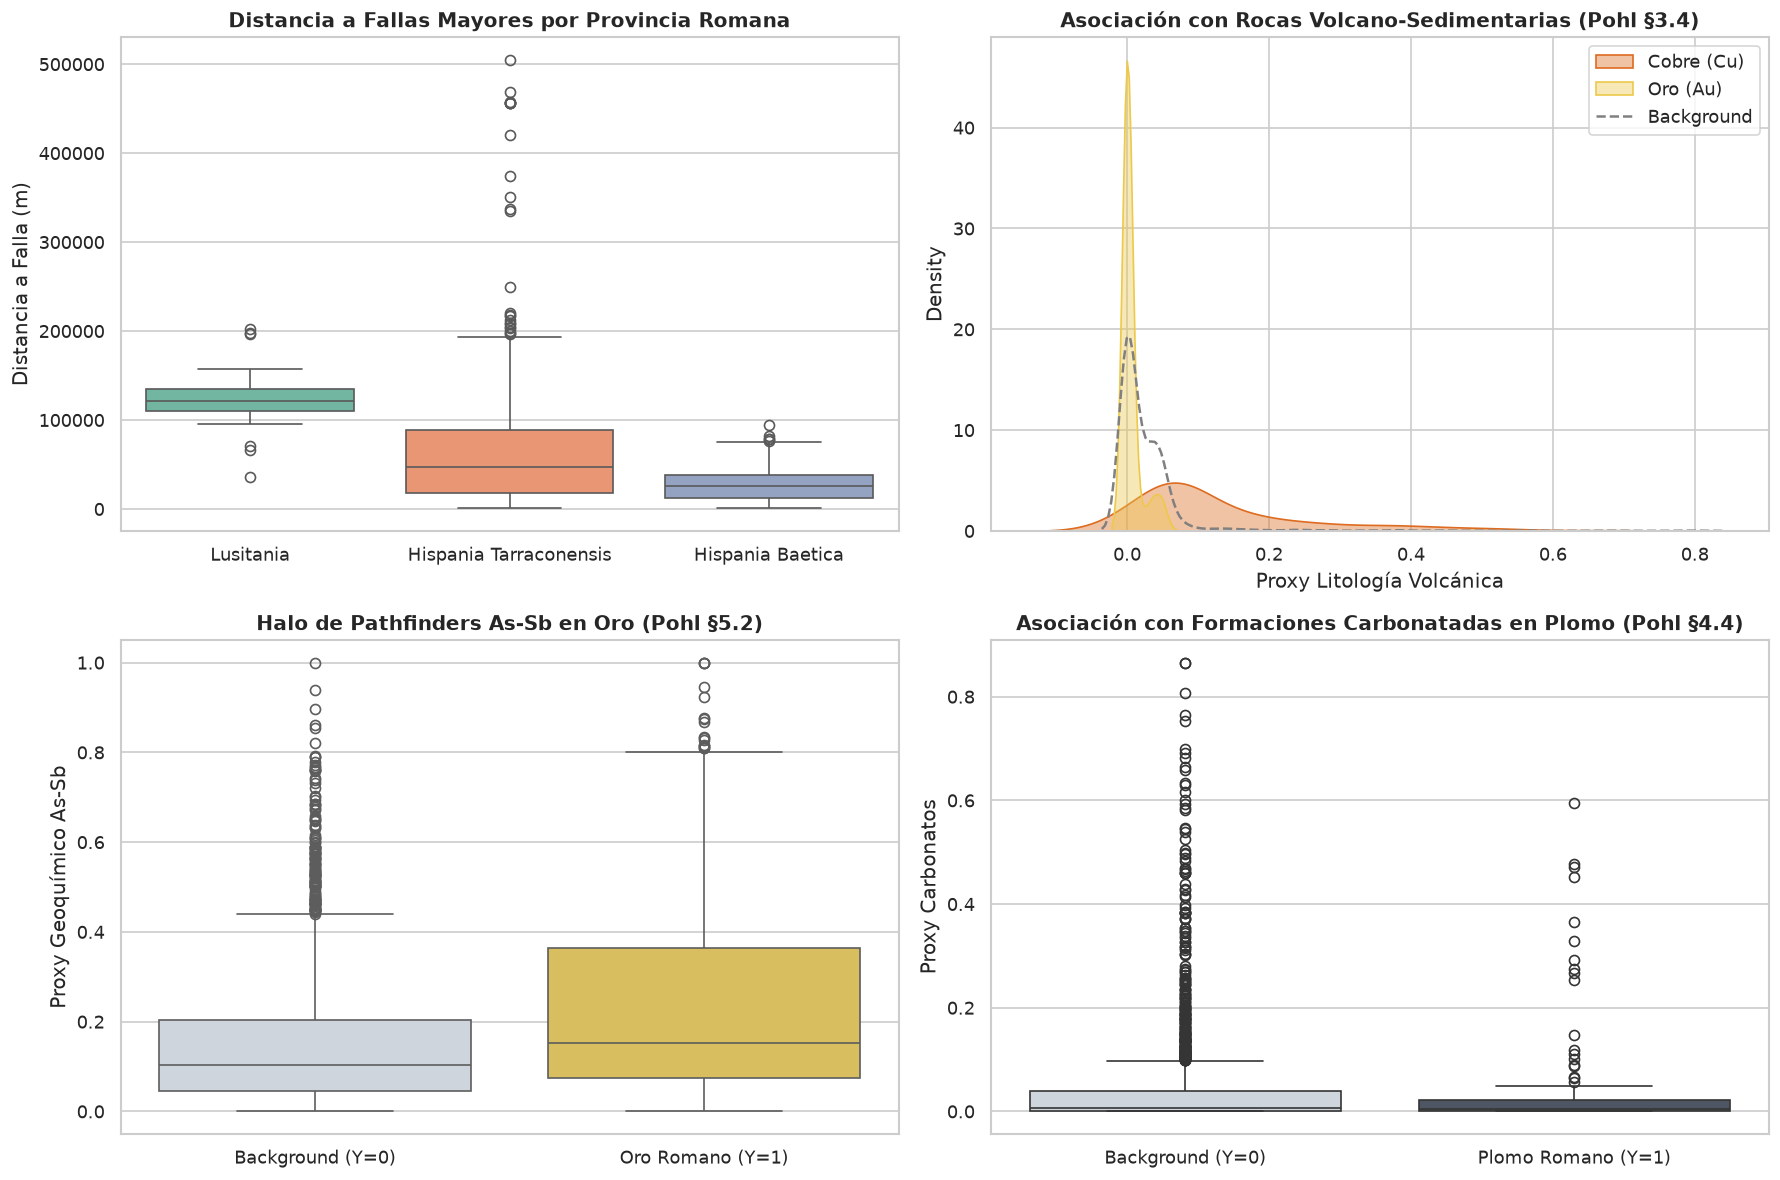

In [9]:
# ==============================================================================
# 6.3 Comparación de Firmas Geocientíficas: Oro vs Cobre vs Plata vs Plomo
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distancia a Fallas por Commodity
sns.boxplot(data=df_master_ml[df_master_ml['Is_Presence']==1], 
            x='province', y='Struct_Dist_MajorFault_m', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distancia a Fallas Mayores por Provincia Romana', fontweight='bold')
axes[0, 0].set_ylabel('Distancia a Falla (m)')
axes[0, 0].set_xlabel('')

# 2. Litología Volcánica en Cobre vs Oro
sns.kdeplot(df_master_ml[df_master_ml['Flag_Cu_Cobre']==1]['Geo_Litho_VolcanicFelsic'], 
            label='Cobre (Cu)', color='#DD6B20', ax=axes[0, 1], fill=True, alpha=0.4)
sns.kdeplot(df_master_ml[df_master_ml['Flag_Au_Oro']==1]['Geo_Litho_VolcanicFelsic'], 
            label='Oro (Au)', color='#ECC94B', ax=axes[0, 1], fill=True, alpha=0.4)
sns.kdeplot(df_master_ml[df_master_ml['Is_Presence']==0]['Geo_Litho_VolcanicFelsic'], 
            label='Background', color='gray', ax=axes[0, 1], linestyle='--')
axes[0, 1].set_title('Asociación con Rocas Volcano-Sedimentarias (Pohl §3.4)', fontweight='bold')
axes[0, 1].set_xlabel('Proxy Litología Volcánica')
axes[0, 1].legend()

# 3. Geoquímica As-Sb en Oro vs Background
sns.boxplot(data=df_master_ml, x='Flag_Au_Oro', y='Geochem_Pathfinder_AsSb', ax=axes[1, 0], palette=['#CBD5E0', '#ECC94B'])
axes[1, 0].set_xticklabels(['Background (Y=0)', 'Oro Romano (Y=1)'])
axes[1, 0].set_title('Halo de Pathfinders As-Sb en Oro (Pohl §5.2)', fontweight='bold')
axes[1, 0].set_ylabel('Proxy Geoquímico As-Sb')
axes[1, 0].set_xlabel('')

# 4. Carbonatos en Plomo vs Background
sns.boxplot(data=df_master_ml, x='Flag_Pb_Plomo', y='Geo_Litho_Carbonate', ax=axes[1, 1], palette=['#CBD5E0', '#4A5568'])
axes[1, 1].set_xticklabels(['Background (Y=0)', 'Plomo Romano (Y=1)'])
axes[1, 1].set_title('Asociación con Formaciones Carbonatadas en Plomo (Pohl §4.4)', fontweight='bold')
axes[1, 1].set_ylabel('Proxy Carbonatos')
axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.show()

---
## 7. Exportación del Dataset Maestro de Machine Learning

Exportamos el dataset maestro estructurado y documentado en formatos interoperables (**Parquet** y **CSV**) en el directorio `data/processed/`, listo para ser consumido por el Cuaderno 03 de modelado supervisado y validación cruzada espacial.

In [10]:
# ==============================================================================
# 7.1 Exportación del Dataset Final
# ==============================================================================
ml_csv_path = os.path.join(PROCESSED_DIR, "master_geoai_ml_dataset.csv")
ml_gpkg_path = os.path.join(PROCESSED_DIR, "master_geoai_ml_dataset.gpkg")

# Exportar a CSV
df_master_ml.to_csv(ml_csv_path, index=False, encoding='utf-8-sig')

# Exportar a GeoPackage (EPSG:25830)
gdf_export = gpd.GeoDataFrame(
    df_master_ml,
    geometry=gpd.points_from_xy(df_master_ml['Coord_X'], df_master_ml['Coord_Y']),
    crs="EPSG:25830"
)
gdf_export.to_file(ml_gpkg_path, layer="master_geoai_ml_points", driver="GPKG")

print("✅ Dataset Maestro de Machine Learning exportado con éxito:")
print(f"   • CSV:         {ml_csv_path} ({os.path.getsize(ml_csv_path)/1024:.1f} KB)")
print(f"   • GeoPackage:  {ml_gpkg_path} ({os.path.getsize(ml_gpkg_path)/1024:.1f} KB)")
print(f"   • Dimensiones: {df_master_ml.shape[0]} observaciones x {df_master_ml.shape[1]} columnas")
print(f"   • Variables predictoras X: {len(feature_cols)}")
print(f"   • Variables objetivo Y: Y_Au, Y_Cu, Y_Ag, Y_Pb")

✅ Dataset Maestro de Machine Learning exportado con éxito:
   • CSV:         c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\data\processed\master_geoai_ml_dataset.csv (608.8 KB)
   • GeoPackage:  c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\data\processed\master_geoai_ml_dataset.gpkg (996.0 KB)
   • Dimensiones: 2979 observaciones x 28 columnas
   • Variables predictoras X: 16
   • Variables objetivo Y: Y_Au, Y_Cu, Y_Ag, Y_Pb
